In [15]:
import sys
print(sys.executable)

/Users/dipasmitadebroy/Documents/Artificial_Intelligence/ml_projects/credit-card-fraud-detection/venv/bin/python


In [13]:
# ── Core ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Preprocessing ─────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

# ── Models ────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# ── Metrics ───────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, f1_score,
    recall_score, precision_score
)

# ── Imbalanced data ───────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Settings ──────────────────────────────────────────
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [7]:
# Load the dataset
#note that the variables are PCA transformed, except for 'Time' and 'Amount'

df = pd.read_csv('../data/raw/creditcard.csv')

print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nNull values:\n", df.isnull().sum())
print("\nFirst 3 rows:")
df.head(3)

Shape: (284807, 31)

Column types:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Null values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0


Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class percentages (%):
 Class
0   99.8270
1    0.1730
Name: proportion, dtype: float64


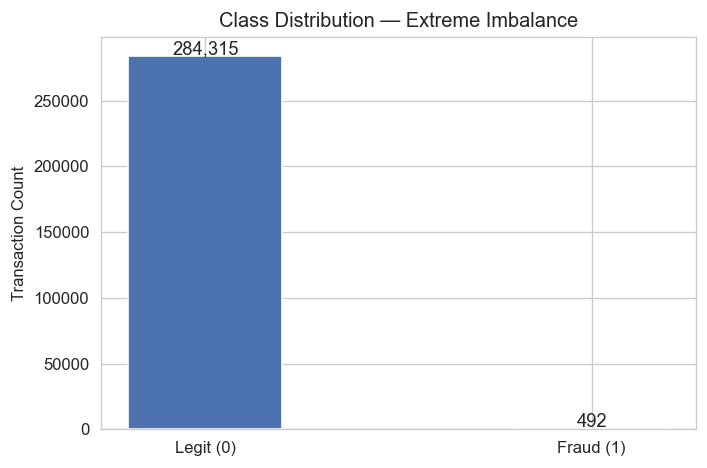

In [8]:
#Class distribution

counts = df['Class'].value_counts()
pct    = df['Class'].value_counts(normalize=True).mul(100).round(3)

print("Class counts:\n", counts)
print("\nClass percentages (%):\n", pct)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Legit (0)', 'Fraud (1)'], counts.values,
       color=['#4C72B0', '#DD8452'], width=0.4)
ax.set_title('Class Distribution — Extreme Imbalance')
ax.set_ylabel('Transaction Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/01_class_distribution.png', dpi=150)
plt.show()

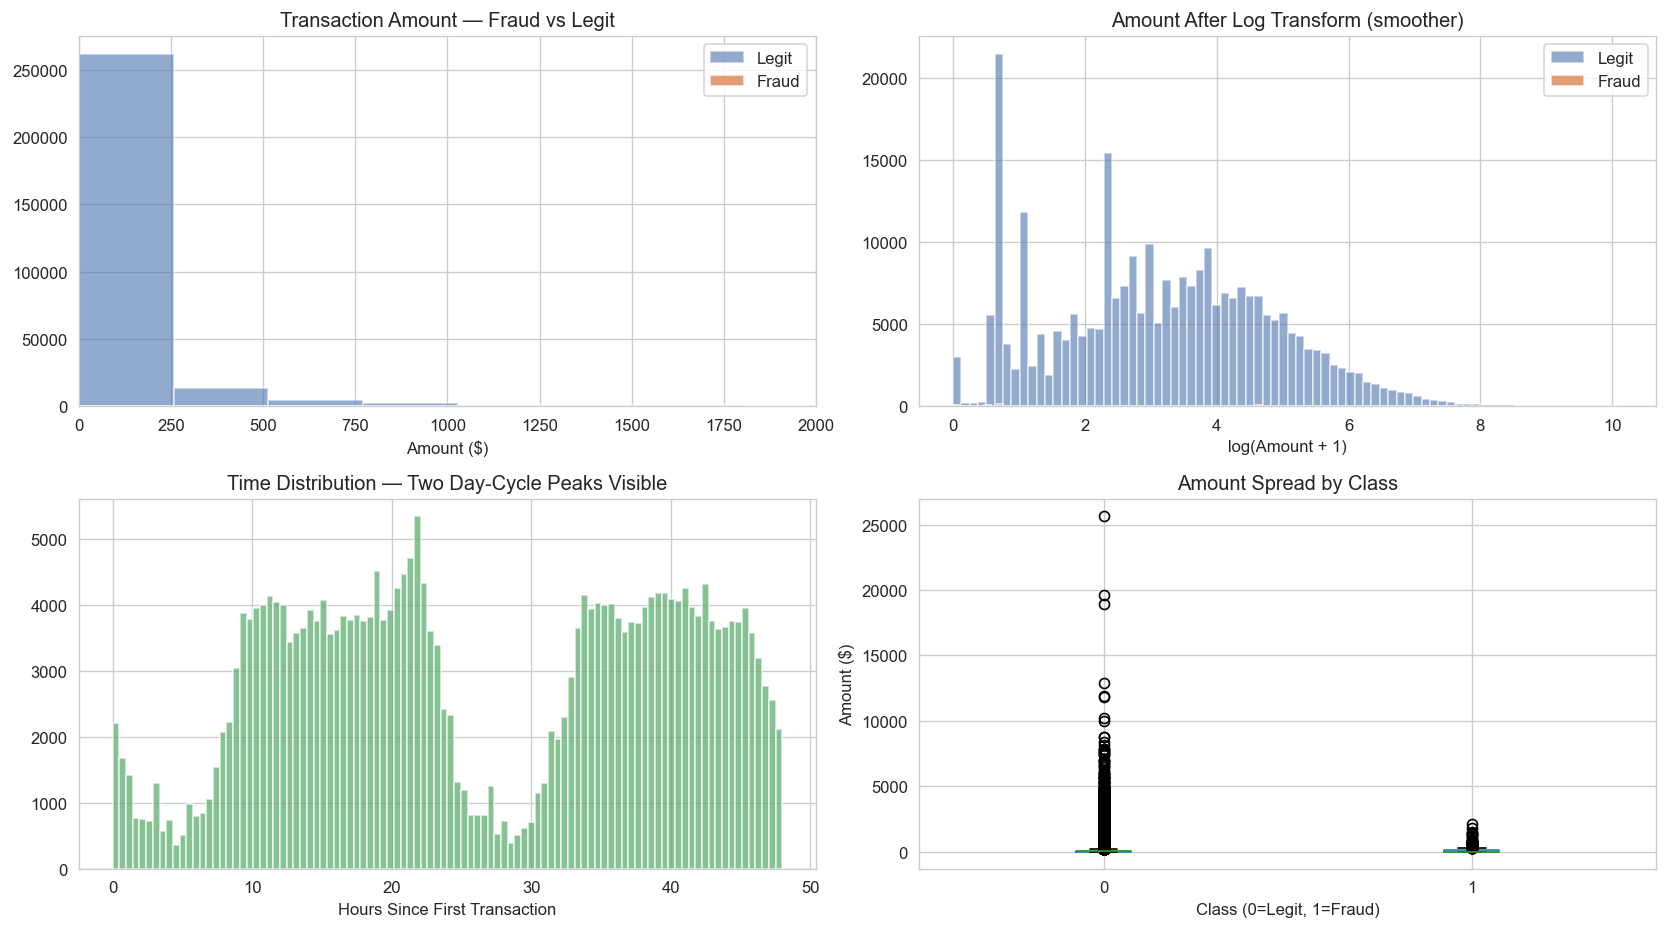

Fraud amount stats:
 count    492.0000
mean     122.2113
std      256.6833
min        0.0000
25%        1.0000
50%        9.2500
75%      105.8900
max     2125.8700
Name: Amount, dtype: float64

Legit amount stats:
 count   284315.0000
mean        88.2910
std        250.1051
min          0.0000
25%          5.6500
50%         22.0000
75%         77.0500
max      25691.1600
Name: Amount, dtype: float64


In [10]:
# amount and time distributions

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Amount: fraud vs legit
axes[0,0].hist(df[df['Class']==0]['Amount'], bins=100,
               color='#4C72B0', alpha=0.6, label='Legit')
axes[0,0].hist(df[df['Class']==1]['Amount'], bins=100,
               color='#DD8452', alpha=0.8, label='Fraud')
axes[0,0].set_xlabel('Amount ($)')
axes[0,0].set_title('Transaction Amount — Fraud vs Legit')
axes[0,0].legend()
axes[0,0].set_xlim(0, 2000)

# Amount after log transformation
axes[0,1].hist(np.log1p(df[df['Class']==0]['Amount']),
               bins=80, color='#4C72B0', alpha=0.6, label='Legit')
axes[0,1].hist(np.log1p(df[df['Class']==1]['Amount']),
               bins=80, color='#DD8452', alpha=0.8, label='Fraud')
axes[0,1].set_xlabel('log(Amount + 1)')
axes[0,1].set_title('Amount After Log Transform (smoother)')
axes[0,1].legend()

# Time distribution (all transactions)
axes[1,0].hist(df['Time'] / 3600, bins=100, color='#55A868', alpha=0.7)
axes[1,0].set_xlabel('Hours Since First Transaction')
axes[1,0].set_title('Time Distribution — Two Day-Cycle Peaks Visible')

# Amount boxplot by class
df.boxplot(column='Amount', by='Class', ax=axes[1,1])
axes[1,1].set_title('Amount Spread by Class')
axes[1,1].set_xlabel('Class (0=Legit, 1=Fraud)')
axes[1,1].set_ylabel('Amount ($)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../reports/figures/02_amount_time.png', dpi=150)
plt.show()

print("Fraud amount stats:\n", df[df['Class']==1]['Amount'].describe())
print("\nLegit amount stats:\n", df[df['Class']==0]['Amount'].describe())

Top 10 most discriminating V features:
feature  p_value  fraud_mean  legit_mean
    V14   0.0000     -6.9717      0.0121
     V4   0.0000      4.5420     -0.0079
    V12   0.0000     -6.2594      0.0108
    V11   0.0000      3.8002     -0.0066
    V10   0.0000     -5.6769      0.0098
     V3   0.0000     -7.0333      0.0122
     V2   0.0000      3.6238     -0.0063
    V16   0.0000     -4.1399      0.0072
     V9   0.0000     -2.5811      0.0045
     V7   0.0000     -5.5687      0.0096


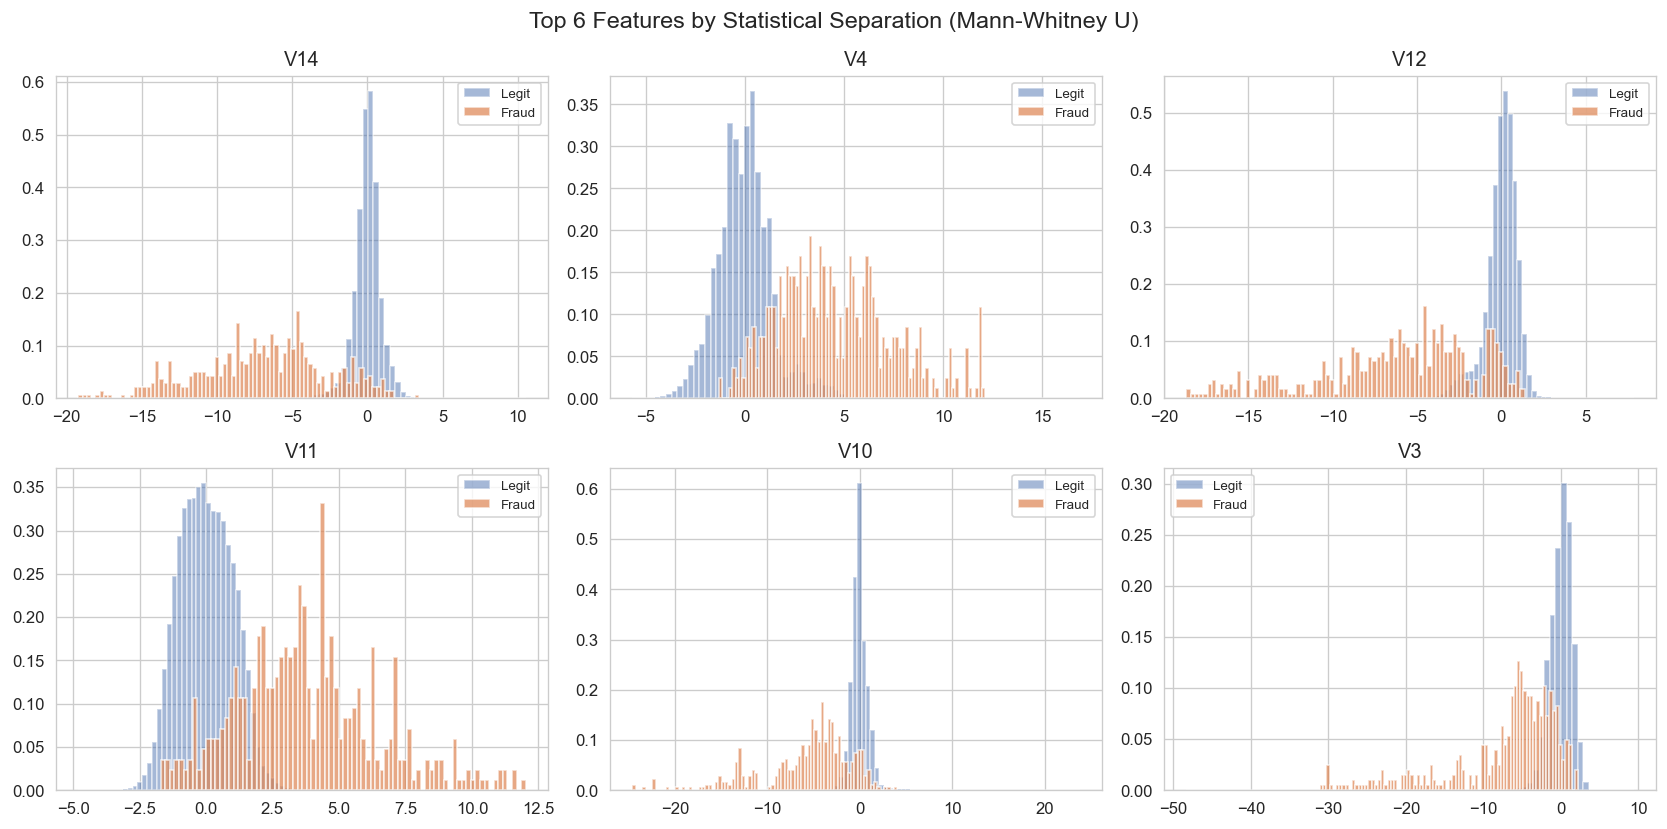

In [11]:
v_cols = [c for c in df.columns if c.startswith('V')]

# Mann-Whitney U test: does the distribution of this feature differ
# significantly between fraud and legit transactions?
results = []
for col in v_cols:
    fraud = df[df['Class']==1][col]
    legit = df[df['Class']==0][col]
    stat, p = stats.mannwhitneyu(fraud, legit, alternative='two-sided')
    results.append({'feature': col,
                    'p_value': p,
                    'fraud_mean': fraud.mean(),
                    'legit_mean': legit.mean()})

feat_df = pd.DataFrame(results).sort_values('p_value')
print("Top 10 most discriminating V features:")
print(feat_df.head(10).to_string(index=False))

# Visualise the top 6 features
top6 = feat_df['feature'].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), top6):
    ax.hist(df[df['Class']==0][col], bins=80,
            color='#4C72B0', alpha=0.5, label='Legit', density=True)
    ax.hist(df[df['Class']==1][col], bins=80,
            color='#DD8452', alpha=0.7, label='Fraud', density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Top 6 Features by Statistical Separation (Mann-Whitney U)', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/03_top_v_features.png', dpi=150)
plt.show()

In [12]:
print("""
EDA SUMMARY
===========
1. Dataset: 284,807 rows × 31 columns — no missing values
2. Class balance: 492 fraud (0.17%) vs 284,315 legit (99.83%)
3. Amount: right-skewed, fraud transactions tend to be smaller
4. Time: two daily cycles visible — frauds distributed throughout
5. V1-V28: PCA-transformed; V14, V17, V12, V10 most discriminating
6. No nulls to handle — this is a clean dataset

The core challenge: EXTREME class imbalance.
We need metrics and techniques that account for this.

Next: Feature engineering to extract more signal,
then assumption checking before modeling.
""")


EDA SUMMARY
1. Dataset: 284,807 rows × 31 columns — no missing values
2. Class balance: 492 fraud (0.17%) vs 284,315 legit (99.83%)
3. Amount: right-skewed, fraud transactions tend to be smaller
4. Time: two daily cycles visible — frauds distributed throughout
5. V1-V28: PCA-transformed; V14, V17, V12, V10 most discriminating
6. No nulls to handle — this is a clean dataset

The core challenge: EXTREME class imbalance.
We need metrics and techniques that account for this.

Next: Feature engineering to extract more signal,
then assumption checking before modeling.

